In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import joblib

In [3]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print("Shape:", df.shape)

print("\nInformation")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nStatistics")
df.describe()

Shape: (303, 14)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (302, 14)


In [6]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [7]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (302, 13)
Target Shape: (302,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 241
Testing Samples  : 61


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

In [11]:
print("Logistic Regression Results\n")

print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

print("\nClassification Report\n")
print(classification_report(y_test, lr_predictions))

Logistic Regression Results

Accuracy : 0.7868852459016393
Precision: 0.7631578947368421
Recall   : 0.8787878787878788
F1 Score : 0.8169014084507042

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



In [12]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [13]:
print("Decision Tree Results\n")

print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall   :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))

print("\nClassification Report\n")
print(classification_report(y_test, dt_predictions))

Decision Tree Results

Accuracy : 0.8032786885245902
Precision: 0.7441860465116279
Recall   : 0.9696969696969697
F1 Score : 0.8421052631578947

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.61      0.74        28
           1       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



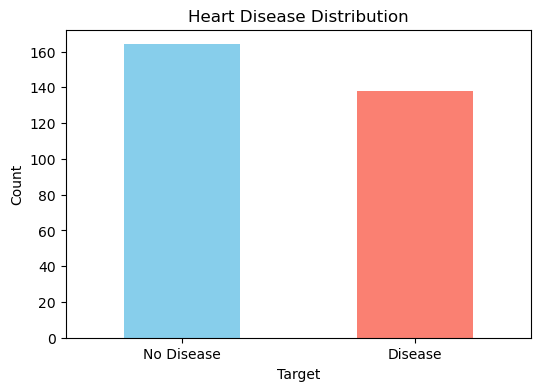

In [14]:
plt.figure(figsize=(6,4))

df["target"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.xticks([0,1], ["No Disease", "Disease"], rotation=0)

plt.show()

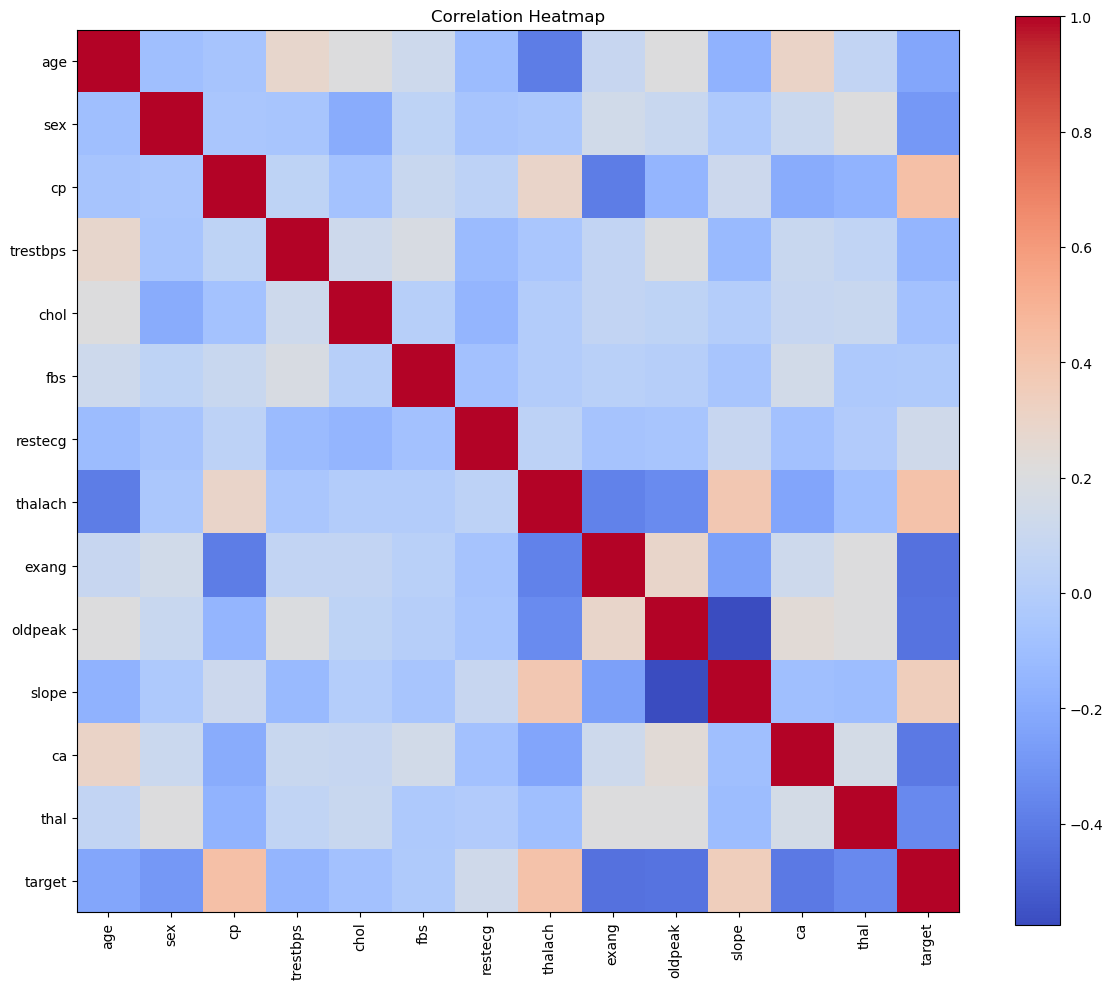

In [15]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

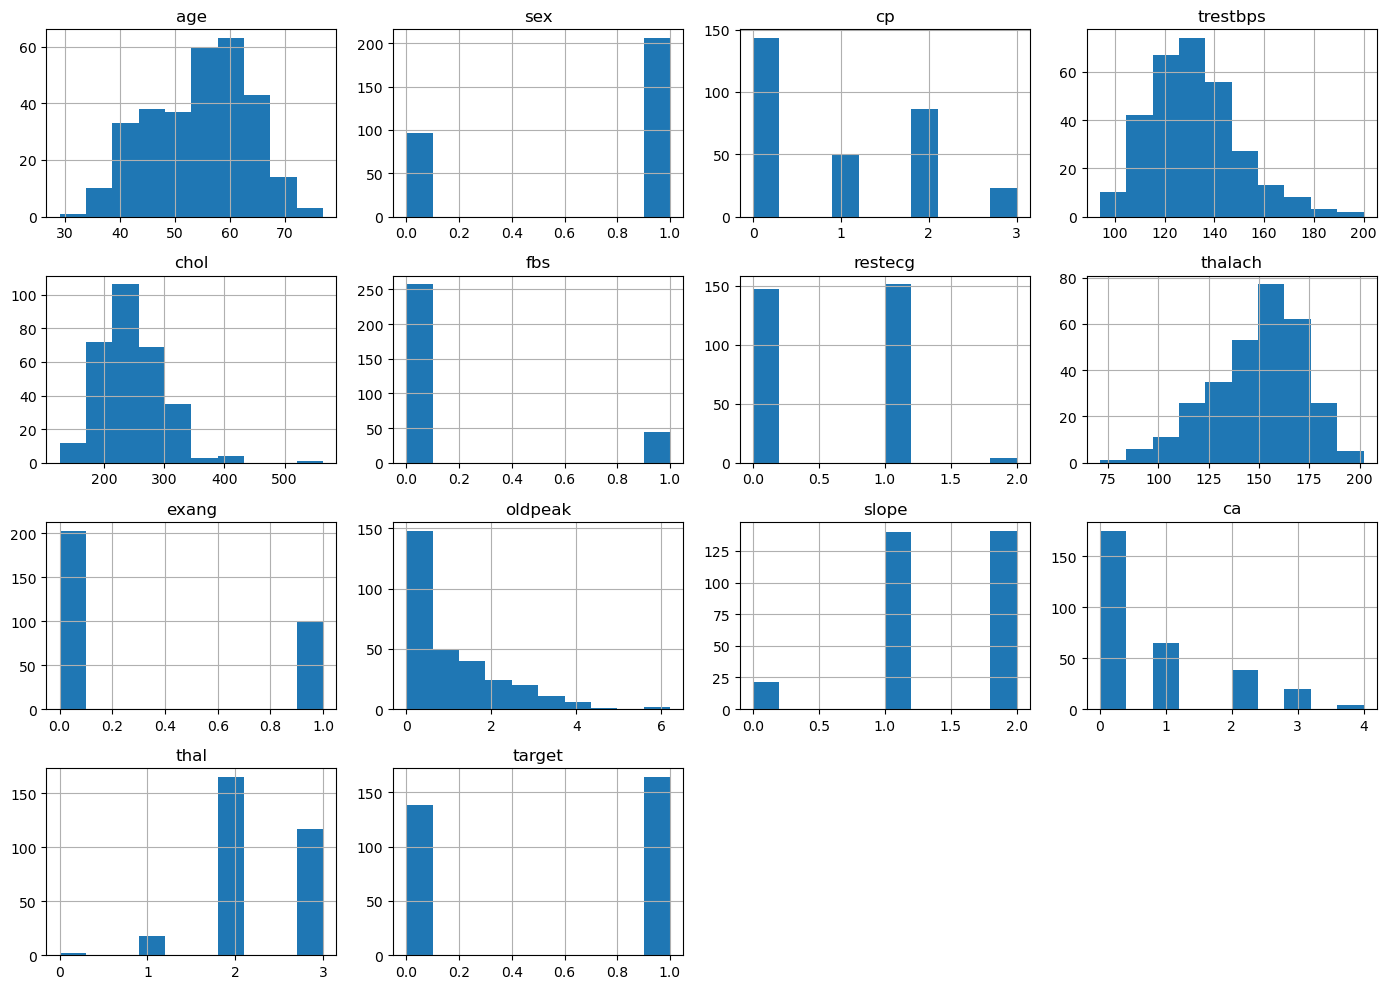

In [16]:
df.hist(figsize=(14,10))

plt.tight_layout()

plt.show()

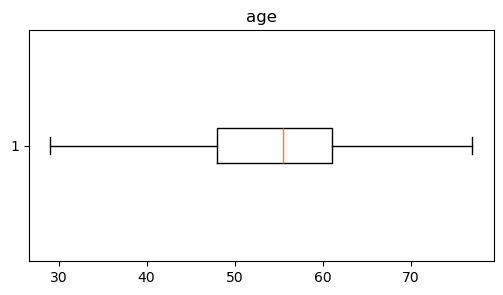

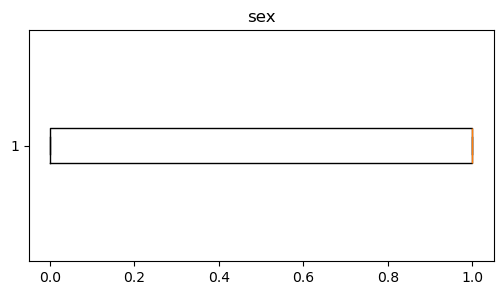

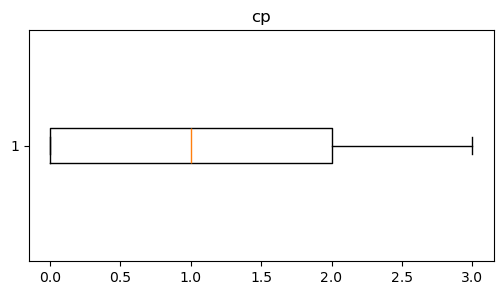

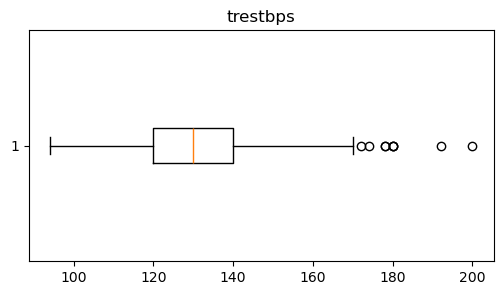

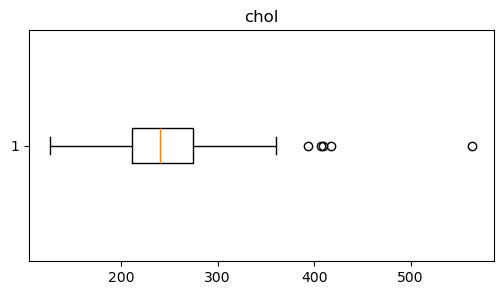

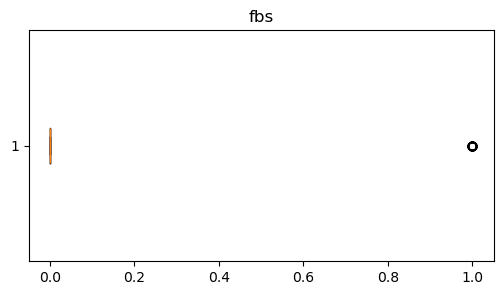

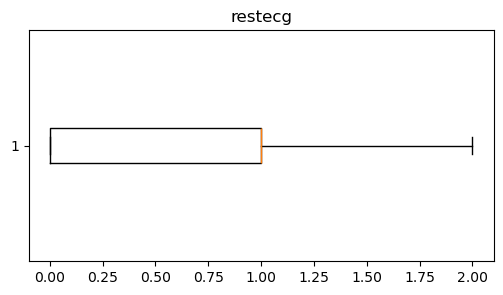

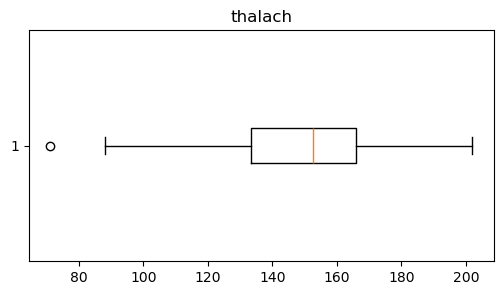

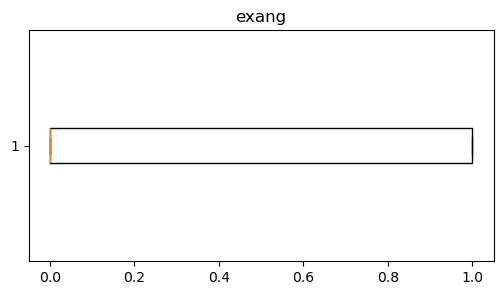

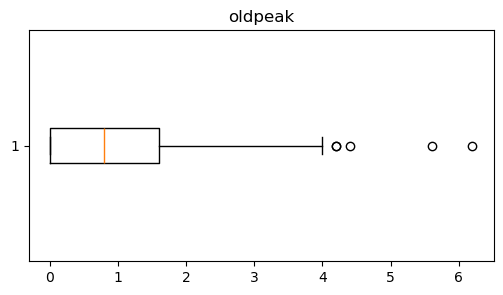

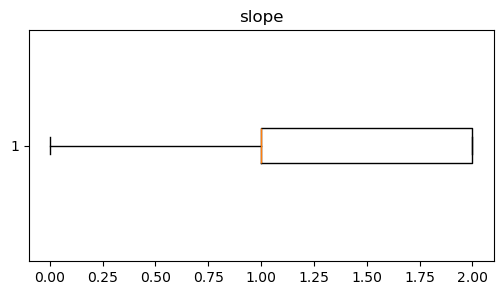

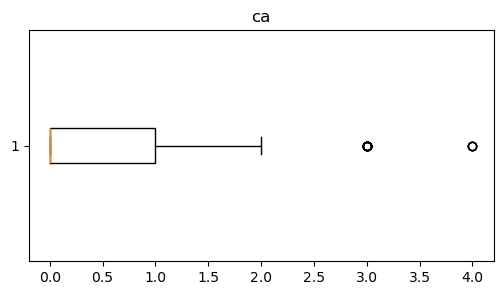

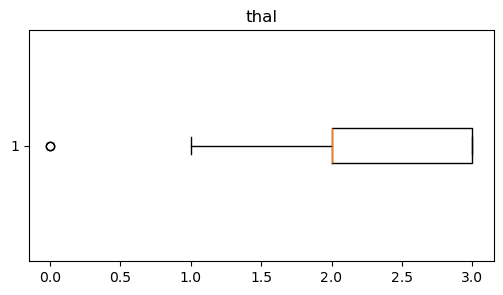

In [17]:
for column in df.columns[:-1]:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[column], vert=False)

    plt.title(column)

    plt.show()

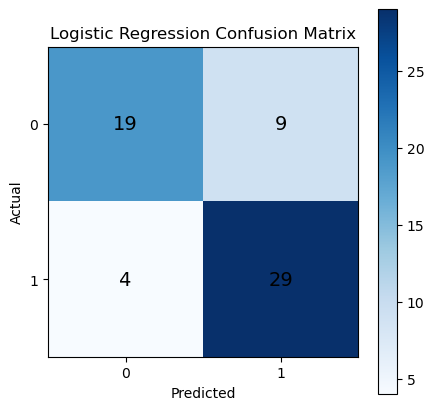

In [18]:
cm_lr = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(5,5))

plt.imshow(cm_lr, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i,j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=14)

plt.xticks([0,1])
plt.yticks([0,1])

plt.show()

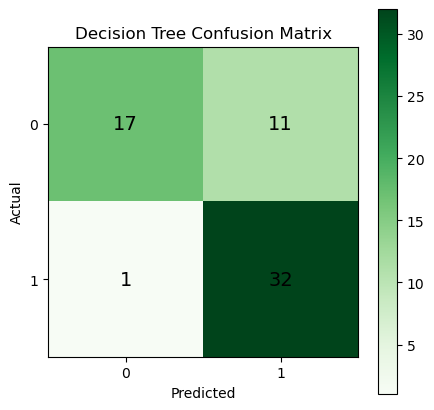

In [19]:
cm_dt = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(5,5))

plt.imshow(cm_dt, cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(j, i, cm_dt[i,j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=14)

plt.xticks([0,1])
plt.yticks([0,1])

plt.show()

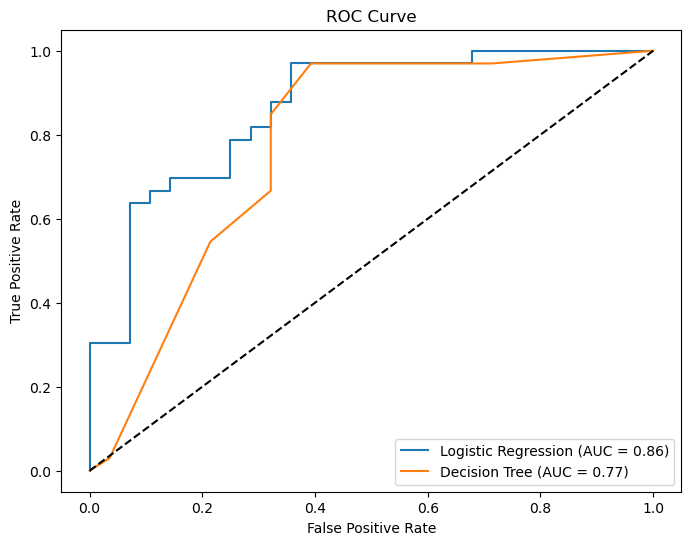

In [20]:
lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]
dt_probs = dt_model.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)

auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {auc_lr:.2f})")

plt.plot(fpr_dt, tpr_dt,
         label=f"Decision Tree (AUC = {auc_dt:.2f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

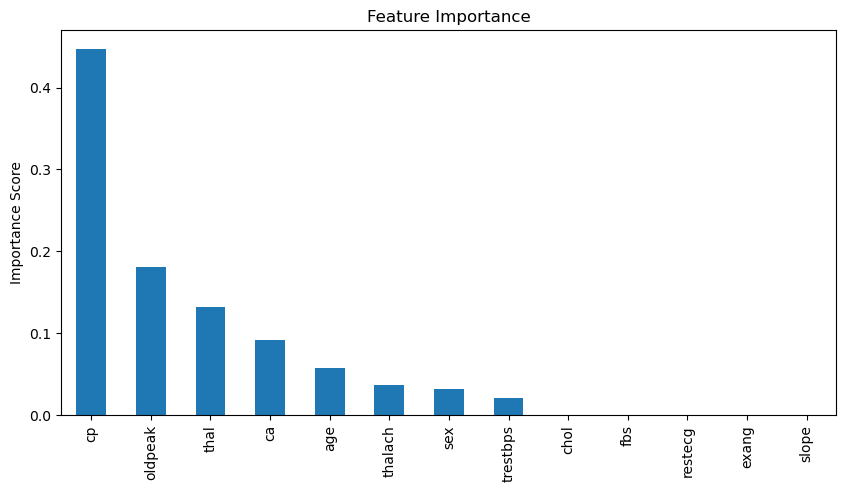

In [21]:
importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

In [22]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions)
    ],
    "Precision": [
        precision_score(y_test, lr_predictions),
        precision_score(y_test, dt_predictions)
    ],
    "Recall": [
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, dt_predictions)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.763158,0.878788,0.816901
1,Decision Tree,0.803279,0.744186,0.969697,0.842105


In [23]:
joblib.dump(lr_model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [24]:
new_patient = [[
    63, 1, 3, 145, 233,
    1, 0, 150, 0,
    2.3, 0, 0, 1
]]

new_patient_scaled = scaler.transform(new_patient)

prediction = lr_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

Heart Disease Detected
